In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from sentence_transformers import SentenceTransformer
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import A2C
import matplotlib.pyplot as plt
import torch

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citations.citation_loader as citation_loader
importlib.reload(citation_loader)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay

In [2]:
users_loader = CitationUsersLoader("../environment/users/datasets/users_relevance_threshold.json")
user_list = users_loader.get_users()
paper_loader = CitationsLoader("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
selector = CitationsSelector()
rater = RuleBasedCitationRater()
reward_shaping = CitationRewardReshapingExpDecay()

In [5]:
env = UserEnv(
        render_mode= "human",
        debug=True,
        debug_path=f"debug_log/user_env_A2C_all_users_random.log",
        items_loader=paper_loader,
        user_list=user_list,
        items_selector=selector,
        reward_shaping=reward_shaping,
        max_interactions=200,
        render_path="./tmp/render/",
    )
env = Monitor(env, filename=f"A2C_alluser_random", info_keywords=("user_id", "item_interact", "item_clicks"))
model = A2C("MultiInputPolicy", env, verbose=1, 
                learning_rate=1e-4,       # You can tune this
                gamma=0.99,               # Discount factor
                n_steps=5,                # Rollout length before updating the model (like batch size)
                ent_coef=0.01,            # Entropy coefficient to encourage exploration
                vf_coef=0.5,              # Value function loss weight
                max_grad_norm=0.5,        # Gradient clipping
                use_rms_prop=True,        # Use RMSprop optimizer (as in original A2C paper)
                normalize_advantage=True, # Helps stability
                device="cpu"              # or "cuda"
                )
model.learn(total_timesteps=90000, progress_bar=False)   
model.save("models/A2C_citation_recommender_baseline")

In [6]:
with open("episode_rewards_A2C.txt", "w") as f:
    for r in env.get_episode_rewards():
        f.write(f"{r}\n")

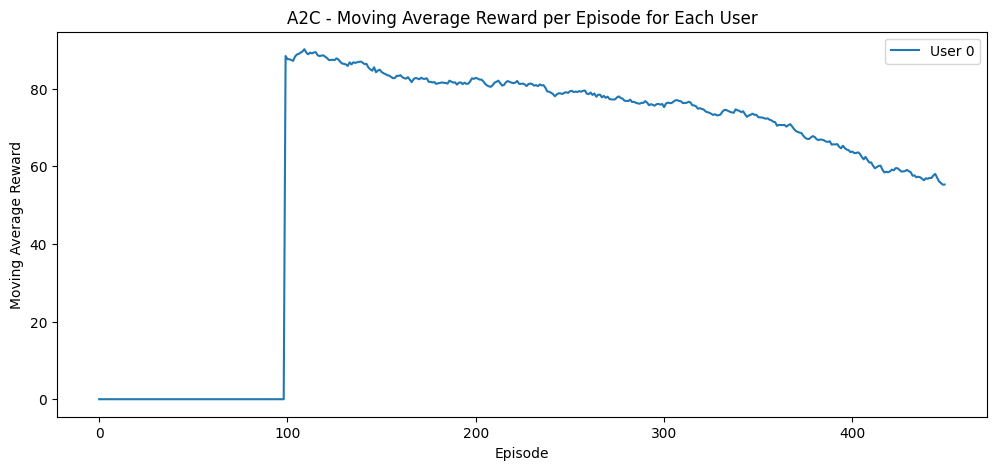

In [7]:
def plot_rewards(all_user_rewards, window_size=100, model=None):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.xlabel('Episode')
    plt.ylabel('Moving Average Reward')
    plt.title(f"{model} - Moving Average Reward per Episode for Each User")

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()

    plt.savefig(
        "export_images/{model} Moving Average Reward.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )

    plt.show()

plot_rewards([env.get_episode_rewards()], model="A2C")

In [15]:
env = UserEnv(
        render_mode= "human",
        debug=True,
        debug_path=f"debug_log/user_env_A2C150000_all_users_random.log",
        items_loader=paper_loader,
        user_list=user_list,
        items_selector=selector,
        reward_shaping=reward_shaping,
        max_interactions=200,
        render_path="./tmp/render/",
    )
env = Monitor(env, filename=f"A2C150000_alluser_random", info_keywords=("user_id", "item_interact", "item_clicks"))
model = A2C("MultiInputPolicy", env, verbose=1, 
                learning_rate=1e-4,       # You can tune this
                gamma=0.99,               # Discount factor
                n_steps=5,                # Rollout length before updating the model (like batch size)
                ent_coef=0.01,            # Entropy coefficient to encourage exploration
                vf_coef=0.5,              # Value function loss weight
                max_grad_norm=0.5,        # Gradient clipping
                use_rms_prop=True,        # Use RMSprop optimizer (as in original A2C paper)
                normalize_advantage=True, # Helps stability
                device="cpu"              # or "cuda"
                )
model.learn(total_timesteps=150000, progress_bar=False)   
model.save("models/A2C_citation_recommender_baseline_150000")

In [16]:
with open("episode_rewards_A2C150000.txt", "w") as f:
    for r in env.get_episode_rewards():
        f.write(f"{r}\n")

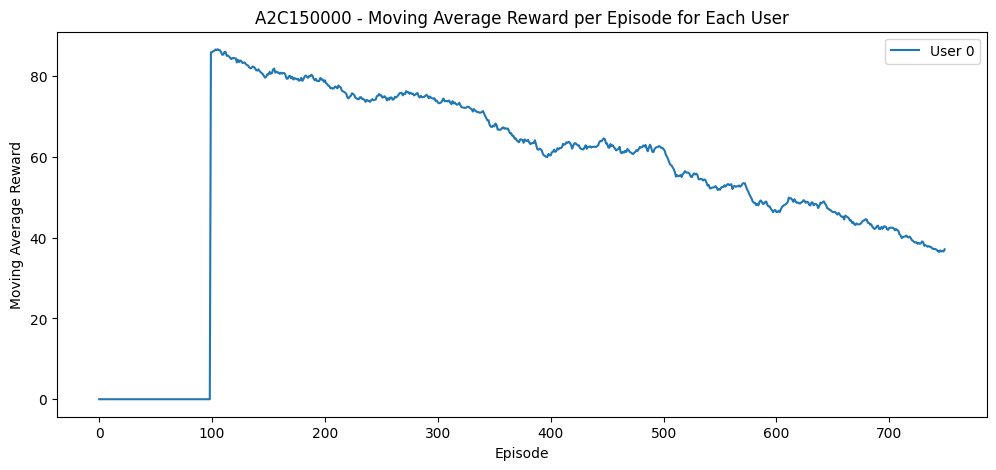

In [17]:
plot_rewards([env.get_episode_rewards()], model="A2C150000")

In [11]:
import pandas as pd
random_A2C_df = pd.read_csv("A2C_alluser_random.monitor.csv", skiprows=1)
random_A2C_df

,r,l,t,user_id,item_interact,item_clicks
0,158.097708,200,3.183649,2,"(46920, 17735, 10070, 25208, 44322, 26950, 400...","(0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, ..."
1,43.877714,200,6.194989,8,"(9392, 731, 40581, 28023, 30710, 25557, 16251,...","(1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, ..."
2,102.937177,200,9.195480,4,"(1479, 15702, 40309, 32794, 19895, 17345, 2145...","(0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, ..."
3,94.452122,200,12.120043,6,"(36317, 17398, 45615, 27671, 13792, 7876, 2294...","(0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, ..."
4,13.487960,200,15.234795,8,"(5137, 38815, 15898, 18991, 12950, 12451, 3261...","(1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...
445,13.093843,200,1413.973313,8,"(27584, 34810, 22605, 48587, 24246, 35912, 926...","(0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, ..."
446,8.430960,200,1417.026786,8,"(42064, 10060, 35156, 7804, 41518, 28451, 2202...","(0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, ..."
447,60.382721,200,1420.290707,3,"(36737, 29244, 35242, 33480, 31777, 14096, 365...","(0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, ..."
448,45.239215,200,1423.522084,6,"(16829, 5319, 29717, 25094, 40932, 16807, 2005...","(0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, ..."


In [146]:
user_rewards = []
timesteps = 30000

for user in user_list:
    env = UserEnv(
        render_mode= "human",
        items_loader=paper_loader,
        user_list=[user],
        items_selector=selector,
        reward_shaping=reward_shaping,
        render_path="./tmp/render/",
        debug=True,
        debug_path=f"debug_log/user_env_A2C_user{user.id}_{timesteps}.log",
    )
    env = Monitor(env, filename=f"monitor_A2C_user{user.id}.csv", info_keywords=("user_id", "item_interact", "item_clicks"))

    model = A2C(
        policy="MultiInputPolicy",
        env=env,
        learning_rate=1e-4,       # You can tune this
        gamma=0.99,               # Discount factor
        n_steps=5,                # Rollout length before updating the model (like batch size)
        ent_coef=0.01,            # Entropy coefficient to encourage exploration
        vf_coef=0.5,              # Value function loss weight
        max_grad_norm=0.5,        # Gradient clipping
        use_rms_prop=True,        # Use RMSprop optimizer (as in original A2C paper)
        normalize_advantage=True, # Helps stability
        verbose=1,
        device="cpu"              # or "cuda"
    )
            
    model.learn(total_timesteps=timesteps)
    user_rewards.append(env.get_episode_rewards())


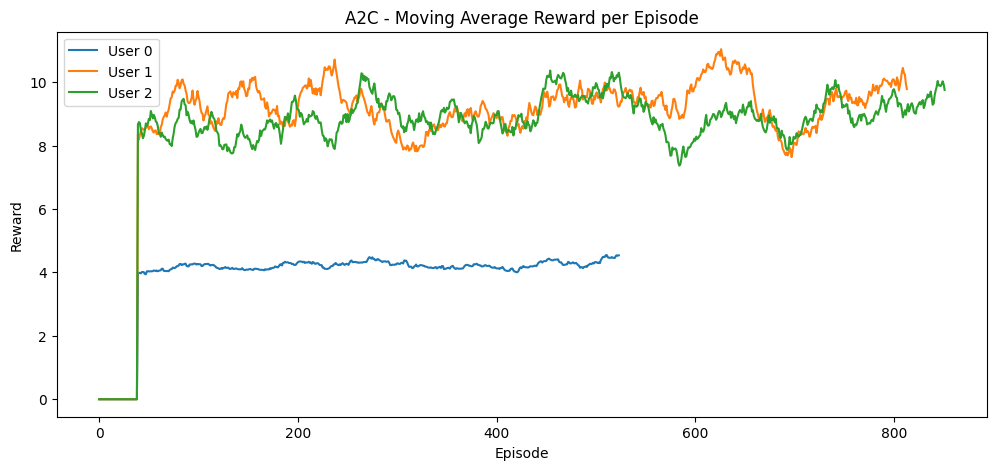

In [147]:
def plot_rewards(all_user_rewards, window_size=40):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.title(f"A2C - Moving Average Reward per Episode")
    plt.xlabel('Episode')
    plt.ylabel('Reward')

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()
    plt.savefig(
        "export_images/A2C Moving Average Reward.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )

    plt.show()

plot_rewards(user_rewards)

In [84]:
import pandas as pd
import re
import ast

In [85]:
def to_int_tuple(s: str):
    # 1) replace np.int64(123) with just 123
    cleaned = re.sub(r'np\.int64\(\s*(\d+)\s*\)', r'\1', s)
    # 2) literal_eval the result to get a Python tuple of ints
    return ast.literal_eval(cleaned)

# apply it to your DataFrame
df = pd.read_csv("monitor_A2C_user0.csv.monitor.csv", skiprows=1)
df['item_interact_tuple'] = df['item_interact'].apply(to_int_tuple)
df['item_clicks_tuple'] = df['item_clicks'].apply(to_int_tuple)

In [86]:
df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].nunique()

22567

In [93]:
interacted_papers_id = df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].unique()
interacted_papers = paper_loader.load_items_from_ids(interacted_papers_id)
recommended_papers = {
    "id": [],
    "title": [],
    "publication_year": [],
    "quartile_year": [],
    "cited_by_count": [],
    "quartile_cite": [],
    "topics": [],
    # "clicked": []
}

for i in range(len(interacted_papers)):
    recommended_papers["id"].append(interacted_papers[i].id)
    recommended_papers["title"].append(interacted_papers[i].title)
    recommended_papers["publication_year"].append(interacted_papers[i].year)
    recommended_papers["quartile_year"].append(interacted_papers[i].quartile_year)
    recommended_papers["cited_by_count"].append(interacted_papers[i].cited_by_count)
    recommended_papers["quartile_cite"].append(interacted_papers[i].quartile_cite)
    recommended_papers["topics"].append(interacted_papers[i].topics)
    # recommended_papers["clicked"].append(df['item_clicks_tuple'][i])

recommended_papers_df = pd.DataFrame(recommended_papers)
recommended_papers_df

,id,title,publication_year,quartile_year,cited_by_count,quartile_cite,topics
0,39906,Chemical Science - the best new journal,2011,0.368687,0,0.000000,"[scientometrics and bibliometrics research, Hi..."
1,40327,Looking for chemistry!,2013,0.464646,0,0.000000,"[scientometrics and bibliometrics research, Ac..."
2,16422,Research productivity: a definition.,1993,0.164983,12,0.797980,"[scientometrics and bibliometrics research, He..."
3,38737,Research Guides: Research Impacts Using Citati...,2011,0.368687,0,0.000000,[scientometrics and bibliometrics research]
4,6432,Is it better or just the same? Article identif...,2006,0.227273,39,0.917172,"[scientometrics and bibliometrics research, Ad..."
...,...,...,...,...,...,...,...
22562,4147,"Finding open access articles using Google, Goo...",2008,0.272727,58,0.944444,"[scientometrics and bibliometrics research, We..."
22563,28207,Exercises in general chemistry and qualitative...,1927,0.031221,0,0.000000,[scientometrics and bibliometrics research]
22564,4175,How Scholarly Is Google Scholar? A Comparison ...,2009,0.303030,55,0.941919,"[scientometrics and bibliometrics research, Re..."
22565,31741,Open access: requirements for researchers,2016,0.626263,0,0.000000,[scientometrics and bibliometrics research]


In [88]:
recommended_papers_df['title'].value_counts()

title
Issue Publication Information                                                                                                                            667
Journal and patent literature                                                                                                                             76
W. M. WELCH SCIENTIFIC COMPANY                                                                                                                            73
VARIAN associates                                                                                                                                         48
Advertisement                                                                                                                                             42
                                                                                                                                                        ... 
Which cities produce more excellent papers than can 

# Evaluation

## Diversity

In [89]:
from sklearn.decomposition import PCA
import numpy as np

In [127]:
dataset = pd.read_csv("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
sampled_dataset = dataset.sample(
    n=recommended_papers_df.shape[0],
    replace=True,                      # allow repeats
    weights='cited_by_count',          # use this column as relative weights
    random_state=42
)

### Topics

In [91]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")
all_embeddings = []
for topics in recommended_papers_df['topics']:
    # get each topic’s 384‑d vector
    vecs = bert_model.encode(topics, convert_to_tensor=False)
    avg = np.mean(vecs, axis=0)
    all_embeddings.append(avg)

embeddings = np.vstack(all_embeddings)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

recommended_papers_df['x'] = coords[:, 0]
recommended_papers_df['y'] = coords[:, 1]

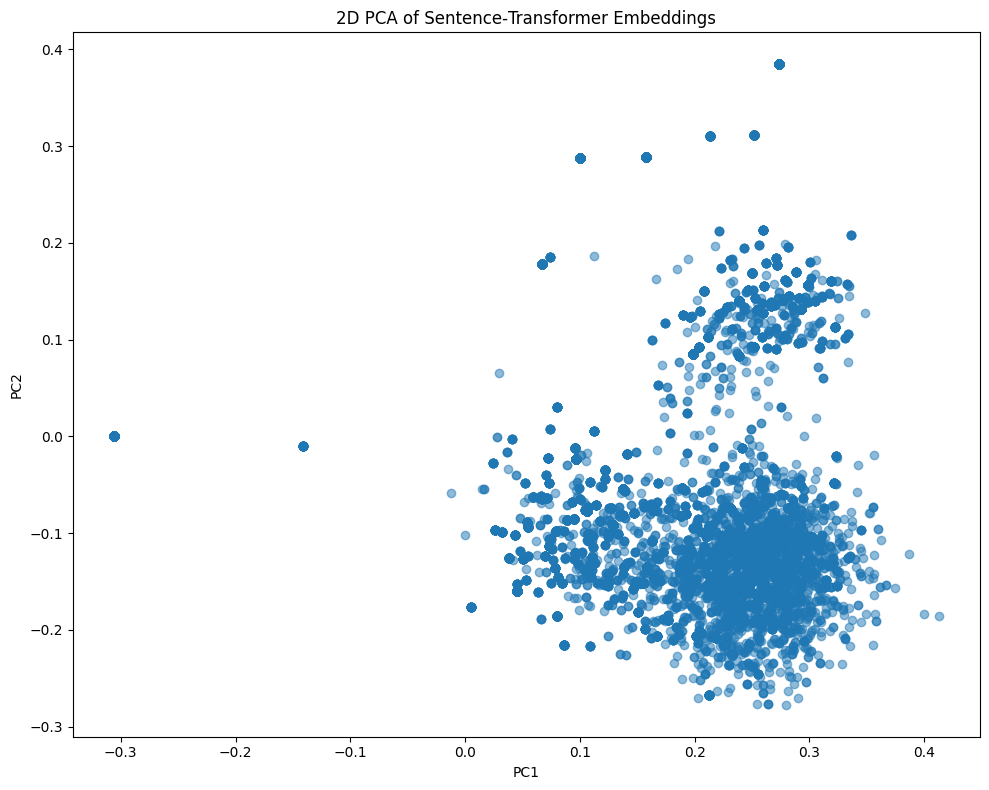

In [92]:
plt.figure(figsize=(10, 8))
plt.scatter(recommended_papers_df['x'], recommended_papers_df['y'], alpha=0.5)
plt.title("2D PCA of Sentence‑Transformer Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

### Novelty

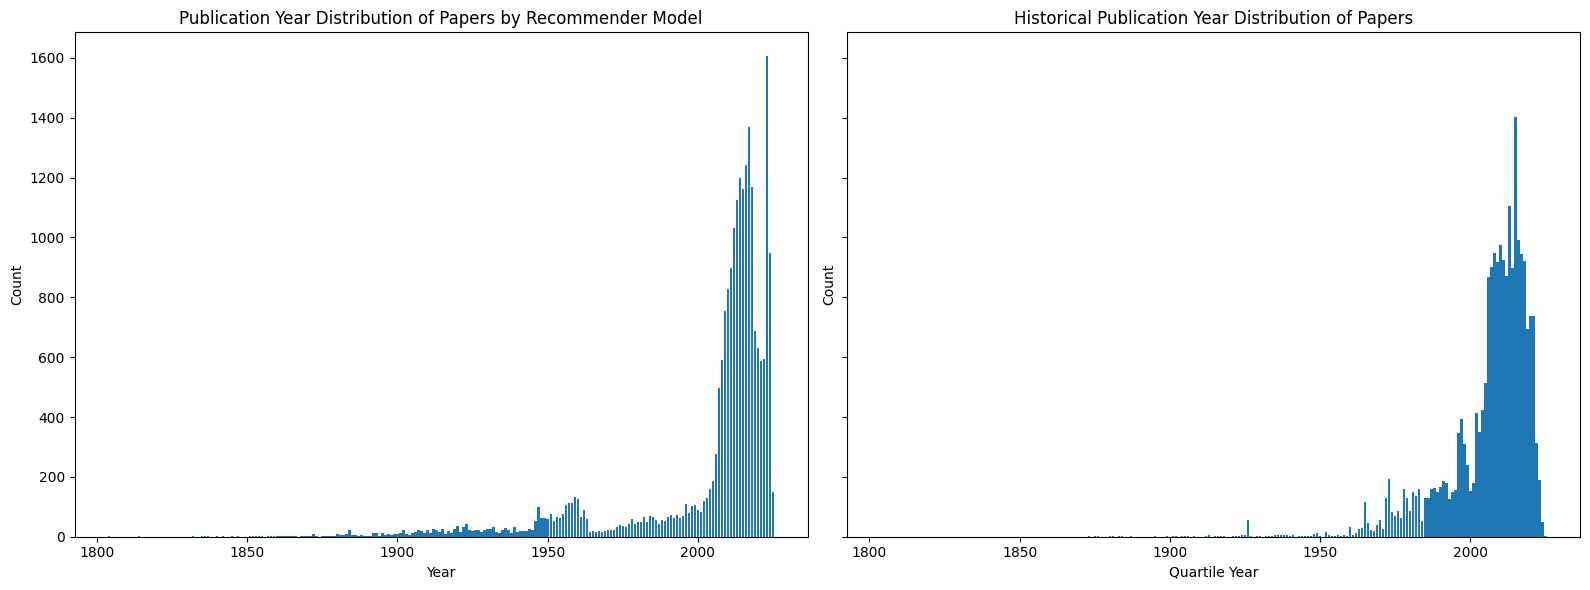

In [135]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

ax1.bar(recommended_papers_df['publication_year'].value_counts().index, recommended_papers_df['publication_year'].value_counts().values)
ax1.set_title("Publication Year Distribution of Papers by Recommender Model")
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")

ax2.bar(sampled_dataset['publication_year'].value_counts().index, sampled_dataset['publication_year'].value_counts().values)
ax2.set_title("Historical Publication Year Distribution of Papers")
ax2.set_xlabel("Quartile Year")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Reputability

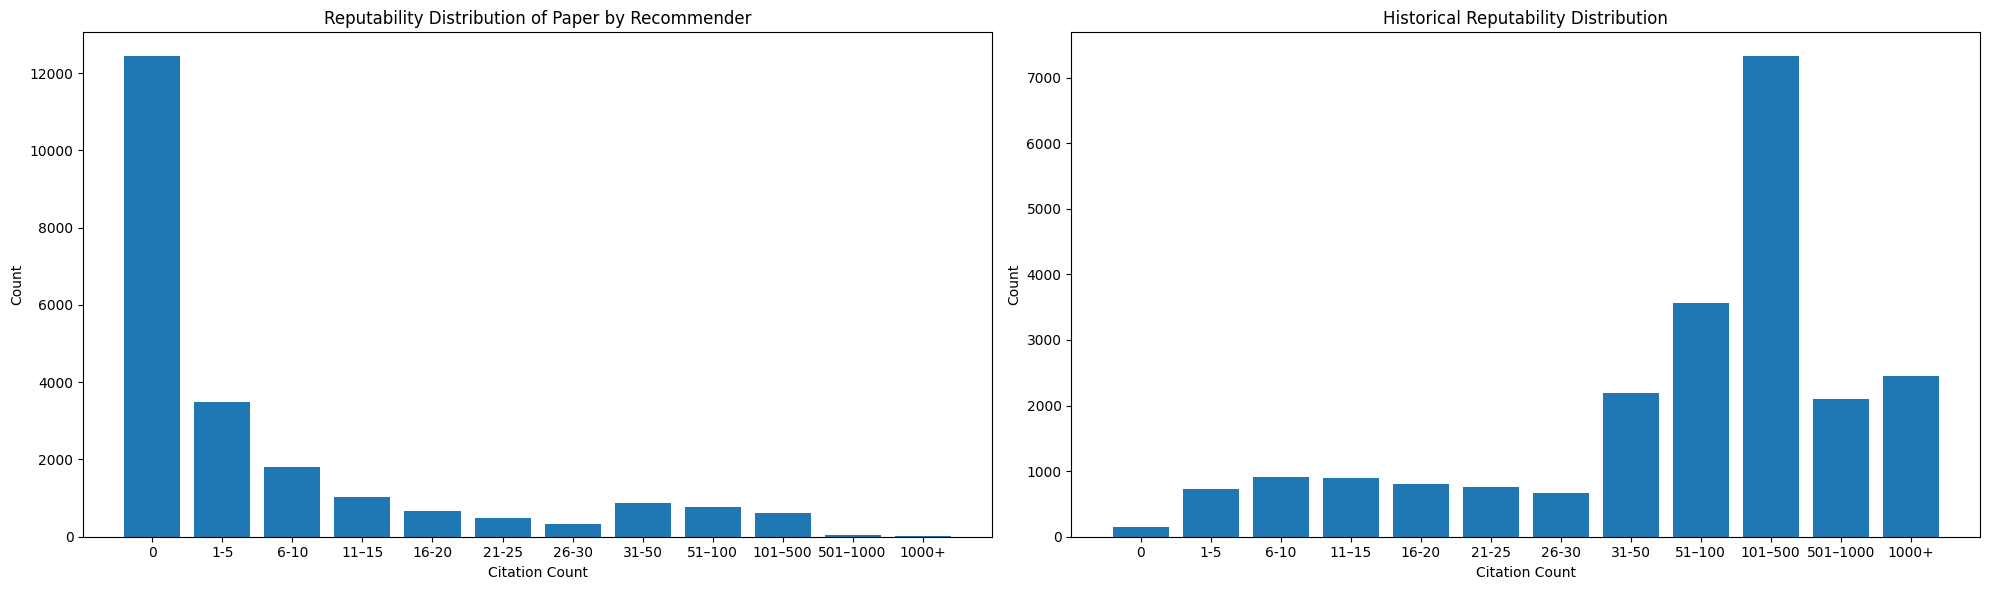

In [140]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

bins = [0, 1, 5, 10, 15, 20, 25, 30, 50, 100, 500, 1000, recommended_papers_df['cited_by_count'].max()]
labels = ['0', '1-5', '6-10', '11–15', '16-20', '21-25', '26-30', '31-50', '51–100', '101–500', '501–1000', '1000+']

cited_by_count = pd.cut(recommended_papers_df['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax1.bar(cited_by_count.index, cited_by_count.values)
ax1.set_title("Reputability Distribution of Paper by Recommender")
ax1.set_xlabel("Citation Count")
ax1.set_ylabel("Count")

dataset_cited_by_count = pd.cut(sampled_dataset['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax2.bar(dataset_cited_by_count.index, dataset_cited_by_count.values)
ax2.set_title("Historical Reputability Distribution")
ax2.set_xlabel("Citation Count")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Overall

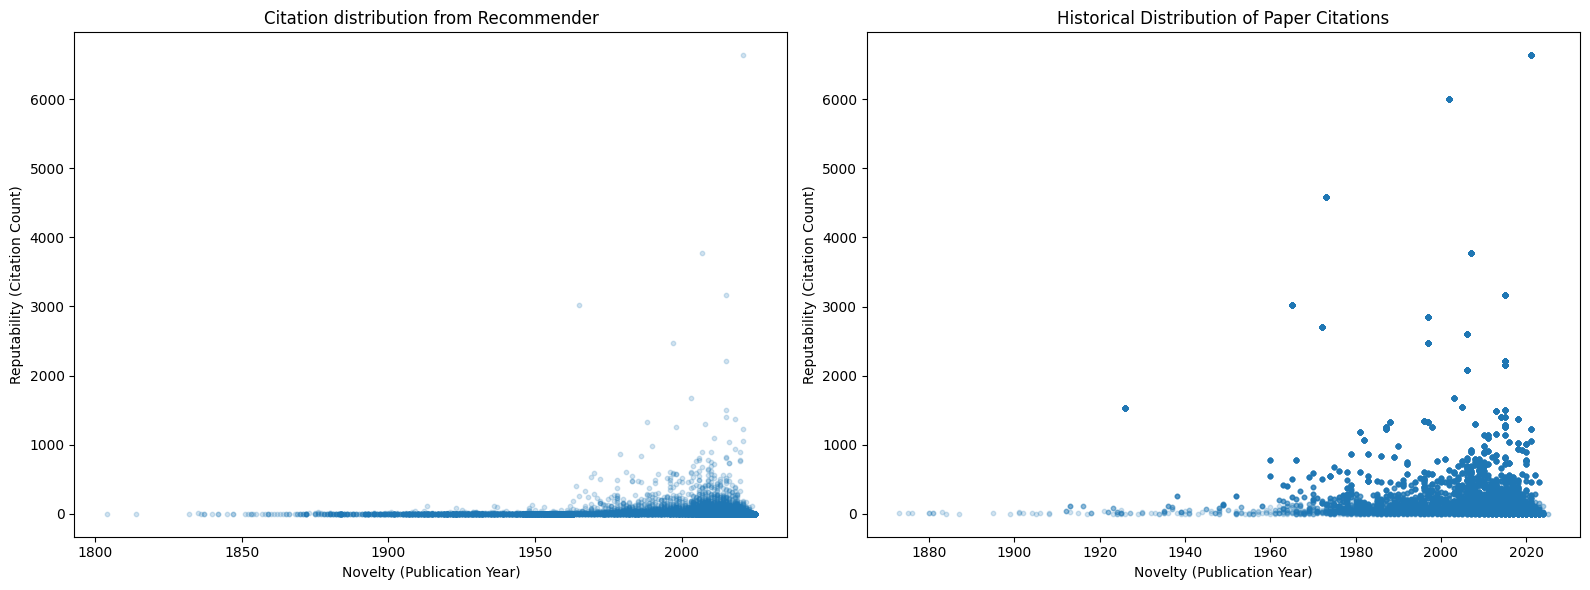

In [141]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(recommended_papers_df['publication_year'], recommended_papers_df['cited_by_count'], alpha=0.2, s=10)
ax1.set_title("Citation distribution from Recommender")
ax1.set_xlabel("Novelty (Publication Year)")
ax1.set_ylabel("Reputability (Citation Count)")

ax2.scatter(sampled_dataset['publication_year'], sampled_dataset['cited_by_count'], alpha=0.2, s=10)
ax2.set_title("Historical Distribution of Paper Citations")
ax2.set_xlabel("Novelty (Publication Year)")
ax2.set_ylabel("Reputability (Citation Count)")

plt.tight_layout()
plt.show()